# 1A ranging-engine QA harness
Continuous validation of the systematic-ranging NEO classifier (`src/ranging_engine.py`).
Design + paper sources: `docs/D2_detail.md`; harness spec: NEOMplan §8. **Gate rule:** a stage's
code does not advance until its plots pass. Re-run top-to-bottom after any engine change.

Stages: **QA0** inputs · **QA1** geometry · **QA2** prior/L0 · (QA3 knob-freeze, QA4 L2 — added next).


In [1]:
import sys, os, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('.'))  # notebooks/qa
import qa_lib as q
ctx = q.load_ctx()
df = pd.read_parquet(q.V5, columns=['mean_ra','mean_dec','mean_dra','mean_ddec','mean_mag',
                                    'mjd0_utc','population','ecl_lon','q_au','P_NEO_d2'])
df['absdlon'] = np.abs(q.antisun_dlon(df.ecl_lon.values, df.mjd0_utc.values))
samp = df.groupby('population', group_keys=False).apply(lambda d: d.sample(min(400,len(d)), random_state=0))
ex = q.pick_exemplars(df)
print('context loaded; sample', len(samp), 'exemplars', [e[0] for e in ex])

context loaded; sample 2000 exemplars ['NEO', 'MBA antisun', 'MBA 40-70', 'TNO']


## QA1a — geometry truth round-trip (already validated in `qa1a_truth_roundtrip.py`)
Feeding TRUE (ρ, ρ̇) from Kurlander truth recovers stored elements to **0.007% median** on a (and e/i/q). Validates earth+observer state (sun-centred, incl. diurnal velocity), the ecliptic rotation for inclination, unit vectors, and the closed-form element formulas.

In [2]:
get_ipython().run_line_magic('run', 'qa1a_truth_roundtrip.py')

QA1a round-trip on 861 Kurlander NEO detections:
  a    median|rel|=0.007%  max|rel|=0.118%(p99)  median|abs|=0.0001223
  e    median|rel|=0.007%  max|rel|=0.254%(p99)  median|abs|=3.309e-05
  i    median|rel|=0.003%  max|rel|=0.222%(p99)  median|abs|=0.0003378
  q    median|rel|=0.003%  max|rel|=0.048%(p99)  median|abs|=2.745e-05
  recovered q<1.3 fraction: 1.000 (truth: all NEO)
  worst a outliers (rec,true): (1.82,1.82) (1.82,1.82) (2.34,2.33)


## QA0 — inputs
### QA0a — NEOMOD3 numerator
Marginals must match Nesvorný+24 (steep N(H) rise to faint); the **(a,e) density must change shape between H=18 and H=25** — that H-dependence of the orbital distribution is the whole reason NEOMOD3 beats the H-independent S3M assumption.

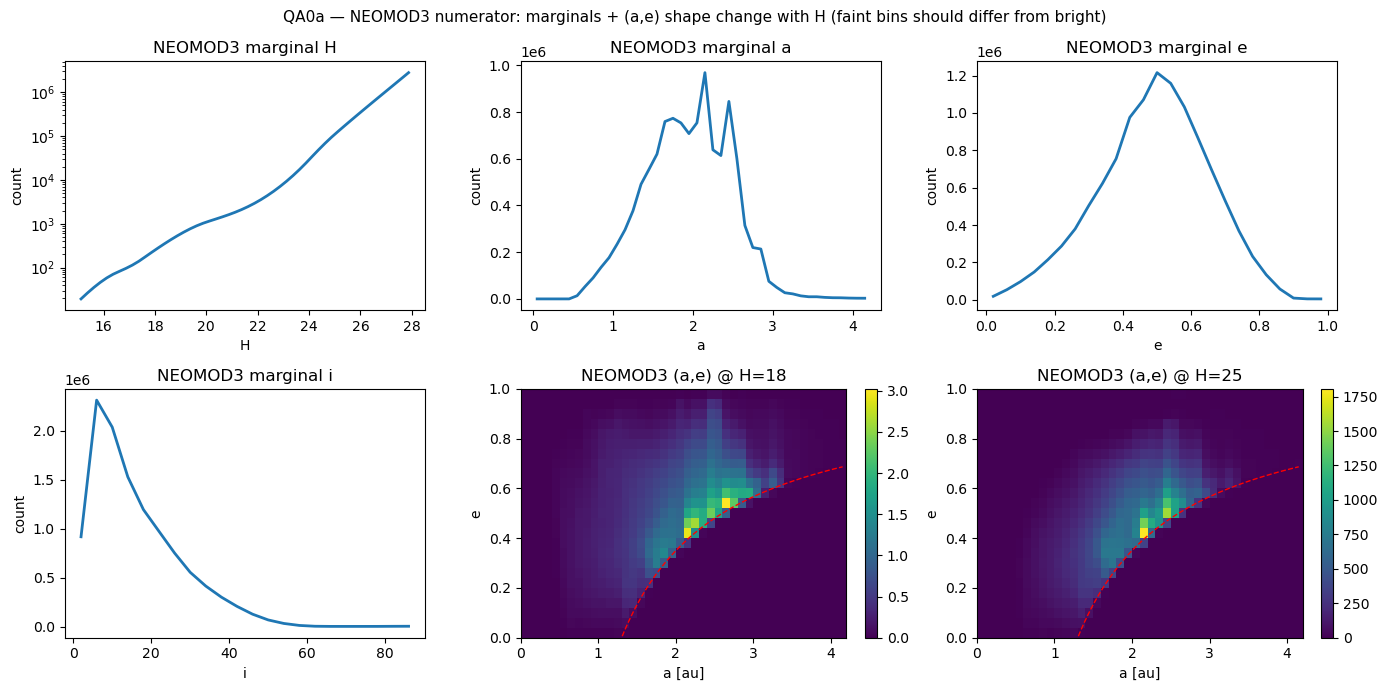

In [3]:
q.qa0a_neomod3(ctx); plt.show()

### QA0b — S3M denominator
MBA (a~1.8–3.3), Trojan (a~5.2), TNO (a~30–70) occupy near-disjoint regions; occupancy justifies the binning. This is the non-NEO density the ranging term divides by.

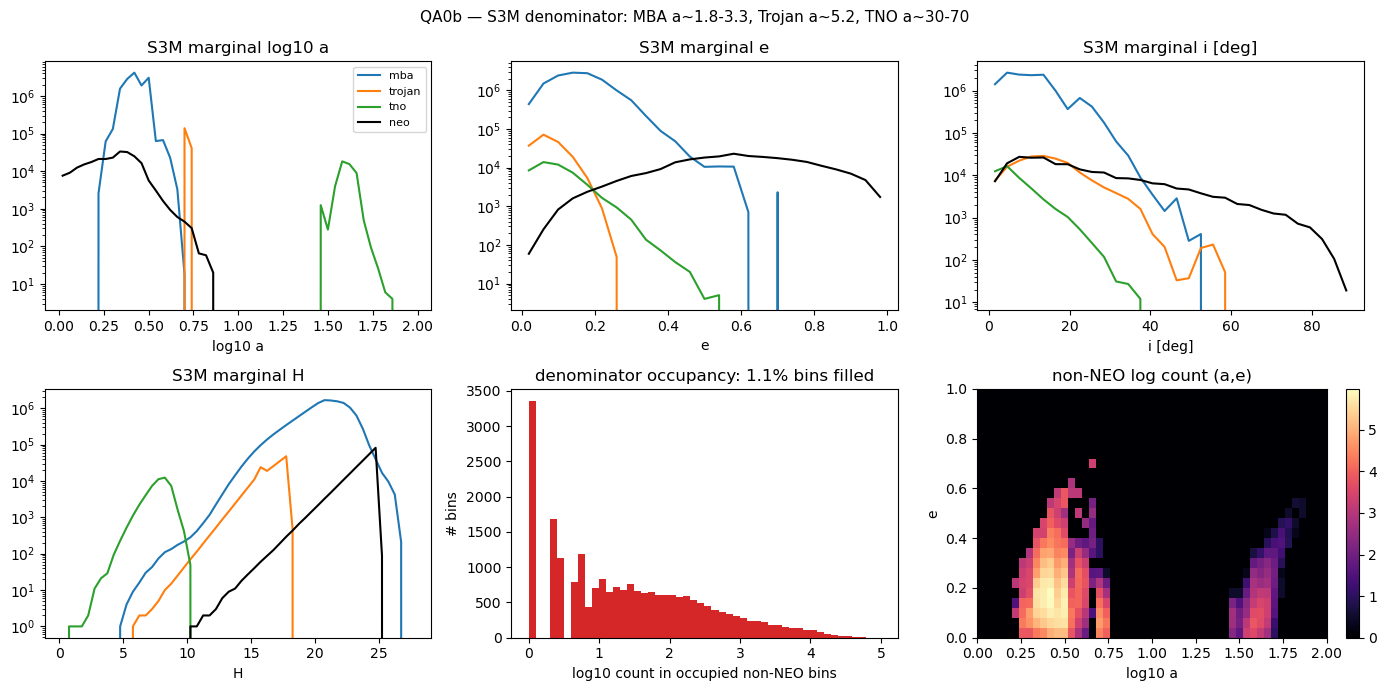

In [4]:
q.qa0b_s3m(ctx); plt.show()

### QA0c — where NEOMOD3 disagrees with S3M-NEO
**Left:** log2(NEOMOD3/S3M-NEO) conditional shape in (a,e) — structured (red near the q=1.3 boundary and low-a Atens) → predicts the (a,e,i) regions where L2 will flip vs L1 (checked in QA4c). **Right:** S3M-NEO's N(H) cuts off at H~25 while NEOMOD3 rises to 28. The default L2 per-H normalisation isolates orbital *shape* (clean 1A test) but inherits S3M's cutoff — **the faint-end N(H) gain is 2B, not 1A.** So expect 1A alone to be a modest shape effect.

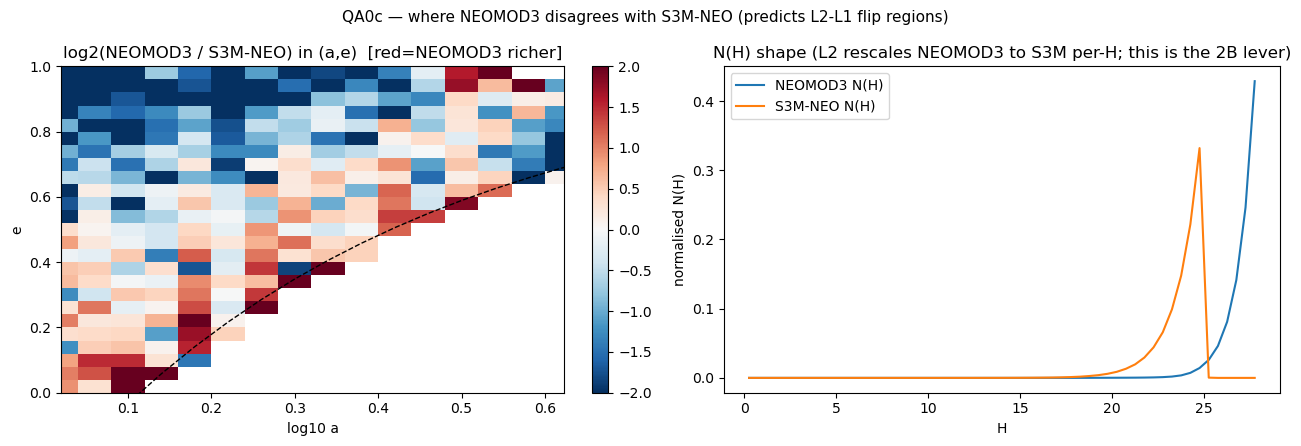

In [5]:
q.qa0c_ratio(ctx); plt.show()

## QA1 — geometry
### QA1b — element maps over (ρ, ρ̇)  [the Farnocchia Fig-1 eyeball check]
Per exemplar: e, q, i, H contours over (ρ, ρ̇); shaded = bound orbits (the Admissible Region). Pass = matches Farnocchia 2015 Fig 1: **H contours ~vertical** (the V↔d↔H coupling), AR closes at large ρ, and the **TNO shows a second admissible component** at ρ~40 au (Spoto's distant-object two-component AR, q>28 au).

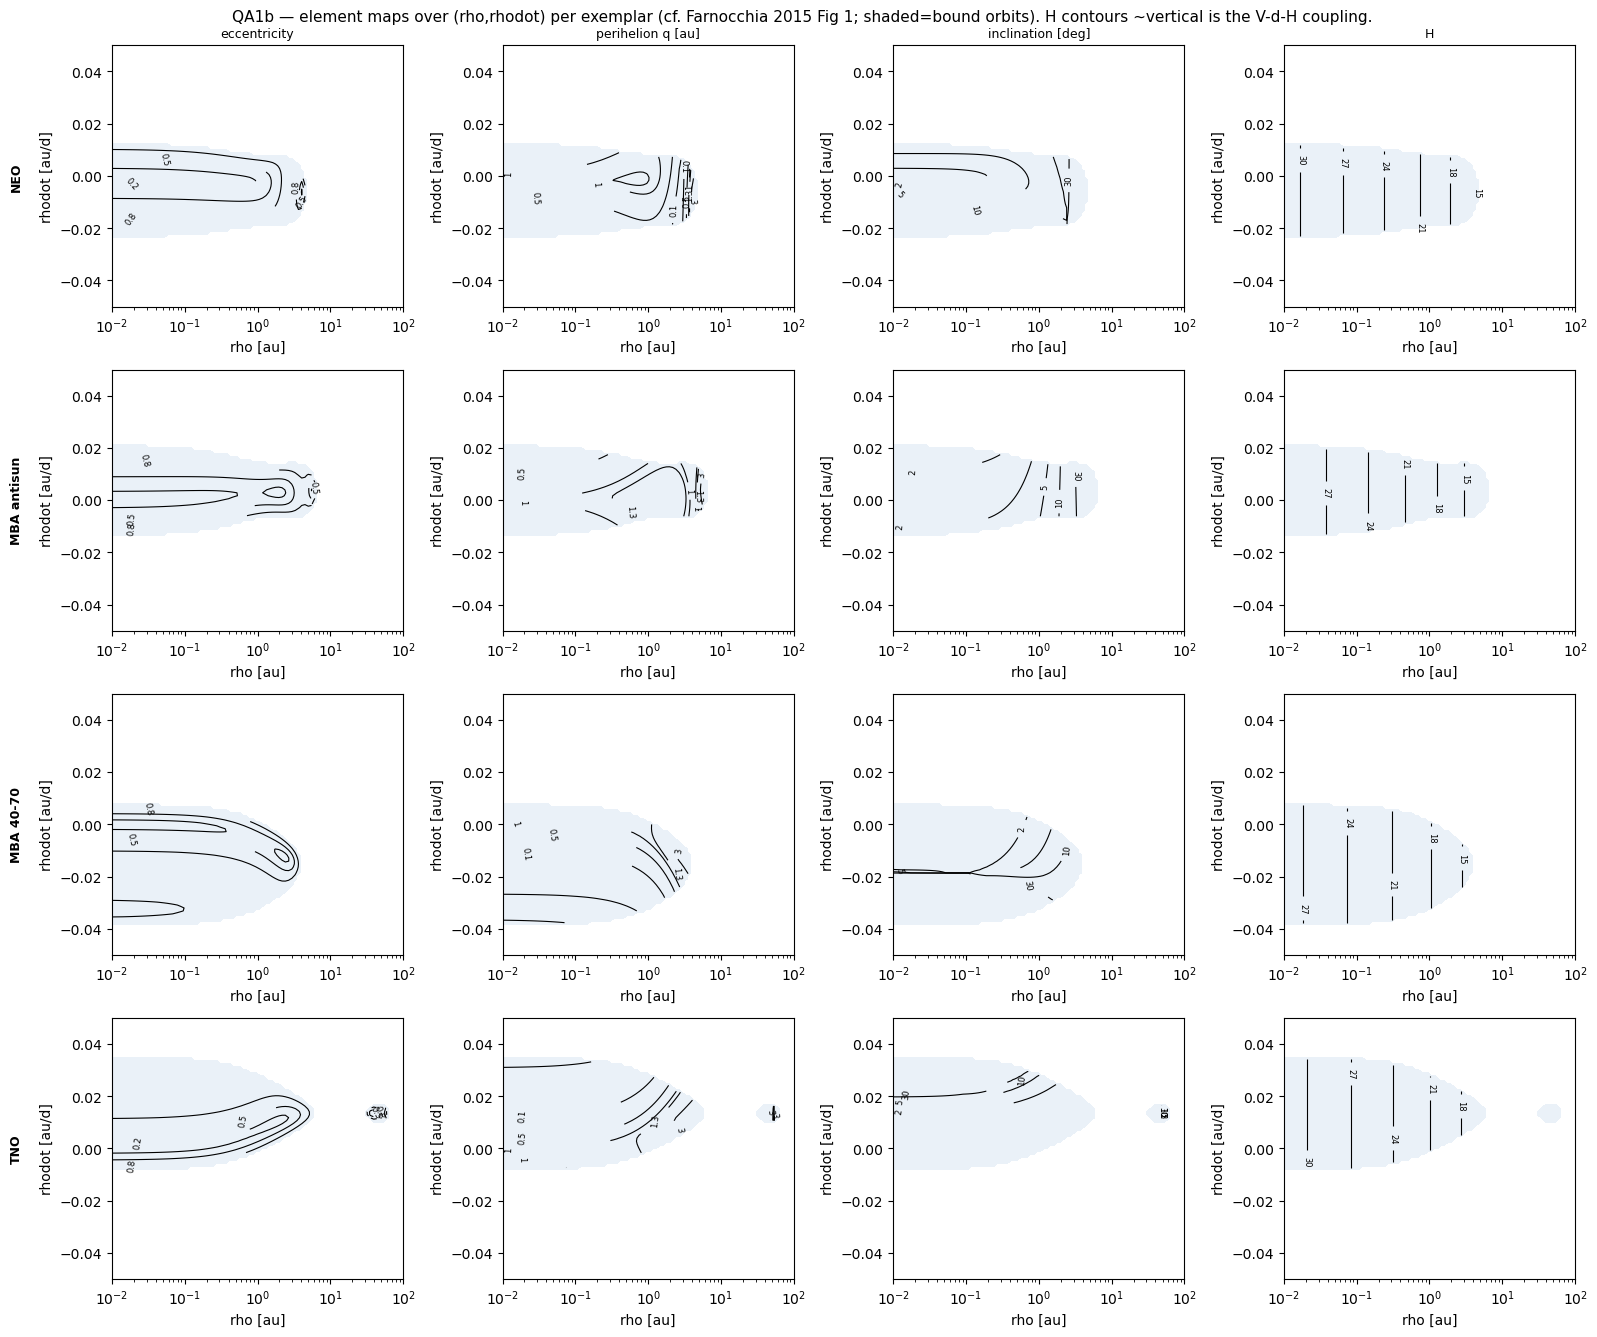

In [6]:
q.qa1b_farnocchia(ex); plt.show()

### QA1c — admissible region vs ρ
Fraction of tracklets with a bound orbit at each ρ, per elongation band. The AR must close at large ρ (energy condition E < −μ/2a_max).

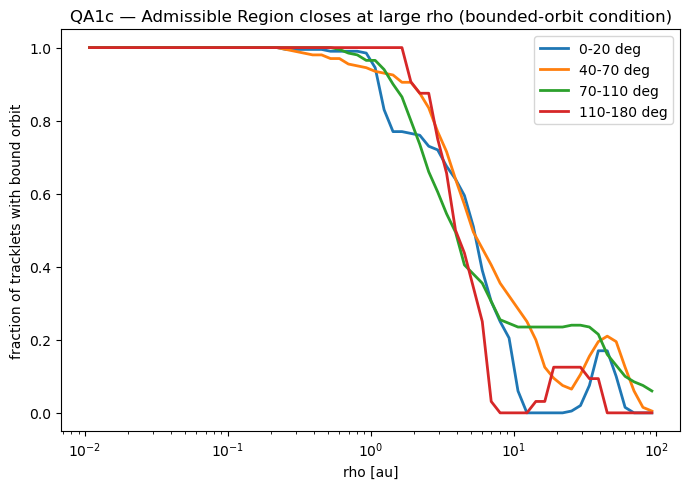

In [7]:
q.qa1c_ar(samp); plt.show()

## QA2 — prior / L0
### QA2a — geometric prior weight maps
w(ρ, ρ̇) for γ = 0, 2, 4 (default 2 = Farnocchia §3.2 ρ² spatial factor). γ shifts weight outward in ρ. Jeffreys' prior is deliberately excluded (Farnocchia Table 3 pathology).

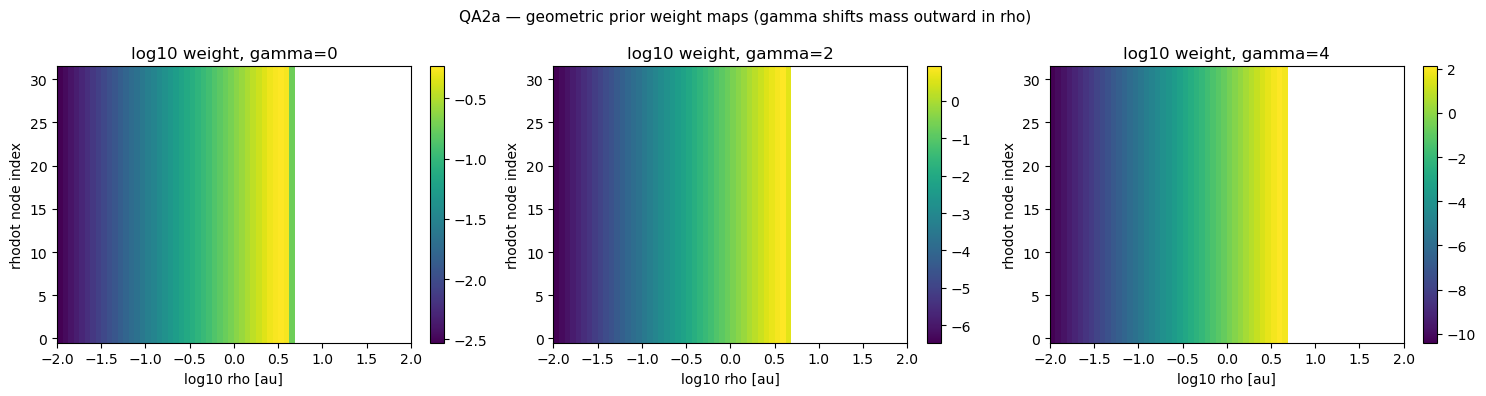

In [8]:
q.qa2a_weights(ex[0][1]); plt.show()

### QA2b — L0 geometric score by class
Pure geometry (no population) already ranks NEO > MBA > Trojan > TNO — this is Spoto et al.'s score and the L0 baseline the population factors build on.

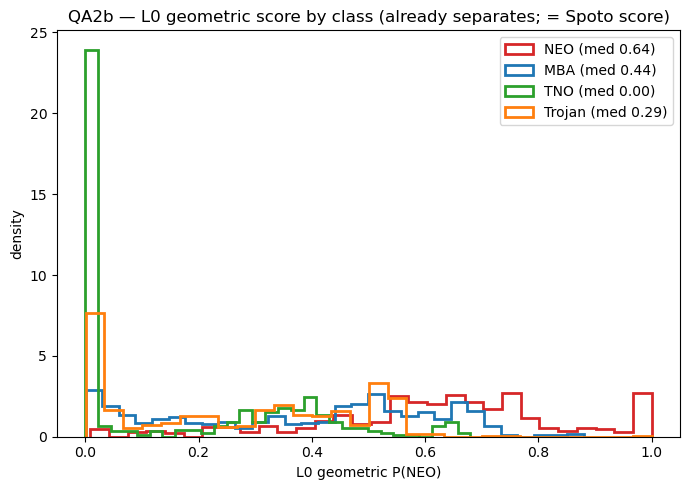

In [9]:
q.qa2b_L0(samp); plt.show()

### QA2c — truth p-value (prior health)
Fraction of admissible weight less likely than the TRUE (ρ, ρ̇), per Kurlander object. **Pass = no spike at 0** (that would be the Jeffreys pathology, Farnocchia Table 3). A uniform distribution is ideal; the current high-skew is a γ-tuning candidate for QA3.

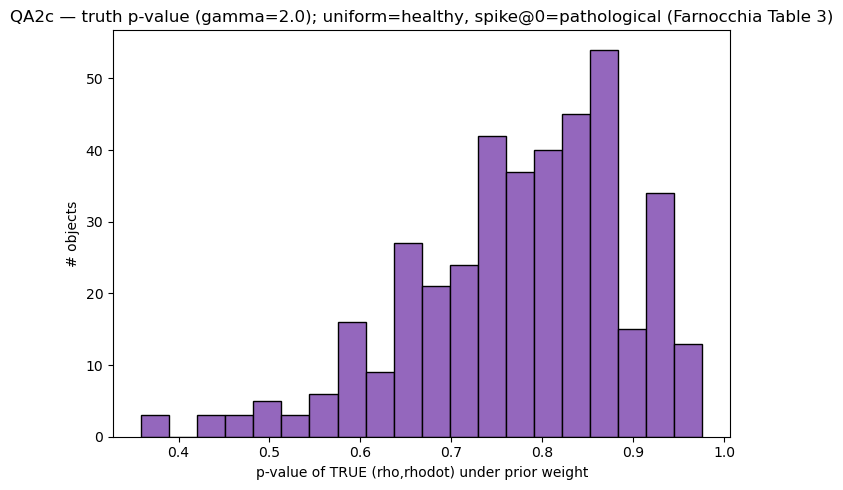

In [10]:
q.qa2c_pvalue(); plt.show()

---
**Next:** QA3 (knob-freeze sweep over γ and grid resolution, maximising L1↔digest2 agreement on the 40–70° band) and QA4 (L2 vs L1 on that band, judged against the pre-registered D5 bar). See NEOMplan §8–9.